In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

df = pd.read_csv("../data/raw/BrentOilPrices.csv")
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.sort_values("Date").reset_index(drop=True)
df = df.set_index("Date")

print(df.shape)
print(df.index.min(), "to", df.index.max())
df.head()

(9011, 1)
1987-05-20 00:00:00 to 2022-11-14 00:00:00


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [8]:
df = df[df.index <= "2022-09-30"]
print(f"Trimmed to: {df.index.min().date()} to {df.index.max().date()}")
print(f"Rows: {len(df)}")

Trimmed to: 1987-05-20 to 2022-09-30
Rows: 8980


In [3]:
print(df.dtypes)
print(f"\nMissing values: {df['Price'].isnull().sum()}")
print(f"\nDuplicate dates: {df.index.duplicated().sum()}")
df.describe()

Price    float64
dtype: object

Missing values: 0

Duplicate dates: 0


,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


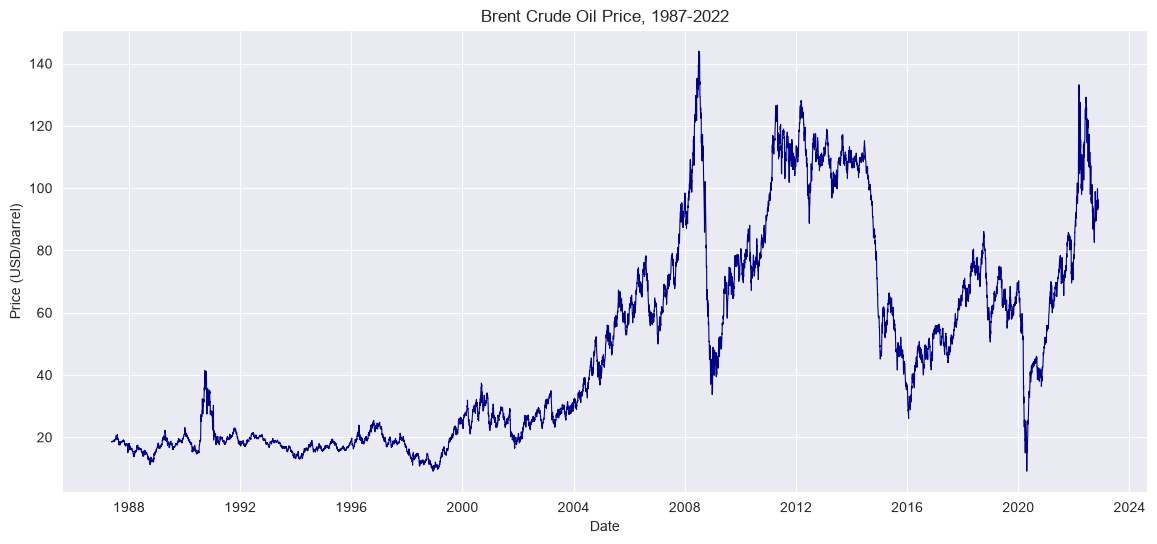

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["Price"], linewidth=0.8, color="darkblue")
ax.set_title("Brent Crude Oil Price, 1987-2022")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
plt.show()

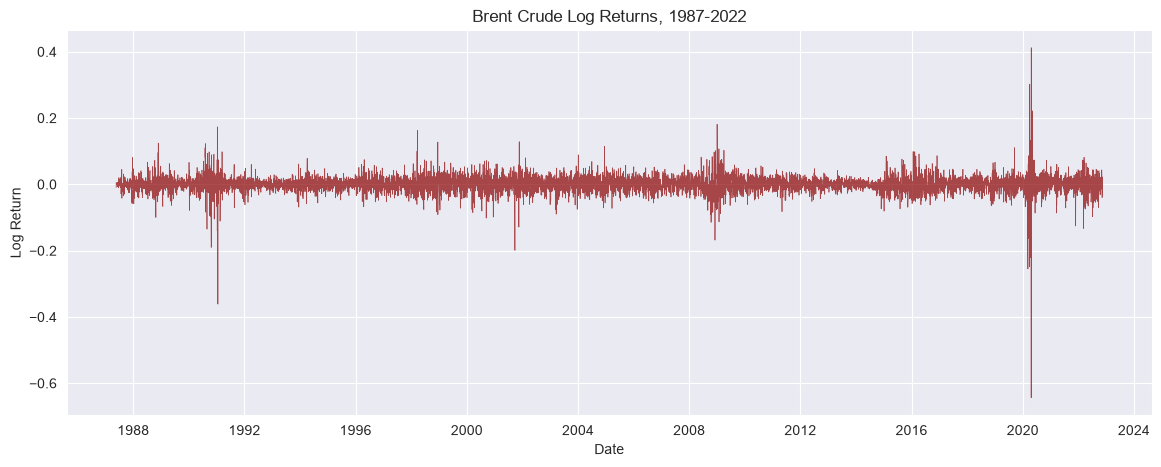

In [5]:
df["Log_Price"] = np.log(df["Price"])
df["Log_Return"] = df["Log_Price"].diff()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Log_Return"], linewidth=0.5, color="darkred", alpha=0.7)
ax.set_title("Brent Crude Log Returns, 1987-2022")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.show()

In [6]:
def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    is_stationary = result[1] < 0.05
    print(f"Stationary: {is_stationary}\n")
    return is_stationary

run_adf(df["Price"], "Raw Price")
run_adf(df["Log_Return"], "Log Return")

--- ADF Test: Raw Price ---
ADF Statistic: -1.9939
p-value: 0.289274
Stationary: False

--- ADF Test: Log Return ---
ADF Statistic: -16.4271
p-value: 0.000000
Stationary: True



np.True_

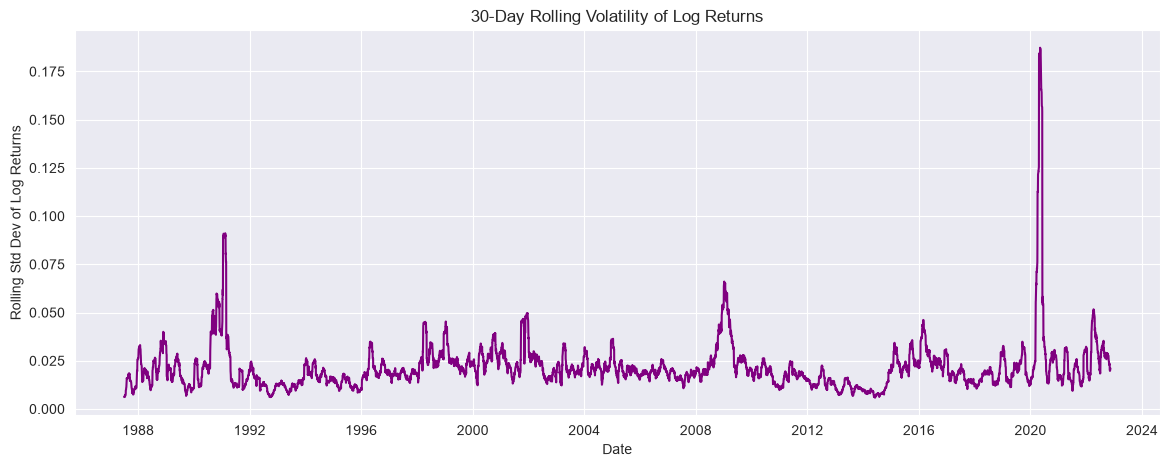

In [7]:
df["Rolling_Volatility_30d"] = df["Log_Return"].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Rolling_Volatility_30d"], color="purple")
ax.set_title("30-Day Rolling Volatility of Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Std Dev of Log Returns")
plt.show()